# Departamento Médico — Classificação de Raio-X (versão modernizada)

Classificação de radiografias de tórax em 4 classes usando **Transfer Learning com ResNet50**:

| Classe (pasta) | Diagnóstico |
|---|---|
| `0` | Covid-19 |
| `1` | Normal |
| `2` | Pneumonia viral |
| `3` | Pneumonia bacteriana |

**Modernizações em relação à versão original (Colab):**
- ✅ Roda **localmente** (sem Google Drive / Colab)
- ✅ APIs atuais do Keras 3: `image_dataset_from_directory`, `model.fit`, `model.evaluate`, formato `.keras`
- ✅ Conjunto de **validação** separado do treino (`validation_split`)
- ✅ **Data augmentation** (rotação, zoom, translação, contraste)
- ✅ Pré-processamento correto da ResNet50 (`preprocess_input` em vez de `1/255`)
- ✅ Treinamento em 2 fases: **feature extraction** (base congelada) + **fine-tuning** (últimas camadas)
- ✅ Callbacks: `ModelCheckpoint`, `EarlyStopping`, `ReduceLROnPlateau`
- ✅ `GlobalAveragePooling2D` no lugar de `AveragePooling2D + Flatten` (menos parâmetros, menos overfitting)

## Experimento: expansão de dados (Dataset Mendeley curado)

Para tentar superar os **80%** de acurácia no `Test/`, o modelo foi re-treinado com um
conjunto **muito maior e balanceado** (4.782 imagens, ~1.200/classe) extraído do dataset
curado do Mendeley *"Curated Dataset for COVID-19 PA Chest Radiography"* (ID `9xkhgts2s6`, v4).

**Cuidados metodológicos:**
- Subconjunto **balanceado** entre as 4 classes (`Dataset_mendeley/0..3`).
- **Deduplicação perceptual (dHash)**: 46 imagens idênticas ao `Test/` foram removidas do treino,
  evitando *data leakage* (o `Test/` original veio do mesmo dataset).
- **Estratégia CPU-friendly**: como não há GPU, foi usada *feature extraction* — cada imagem passa
  **uma vez** pela ResNet50 congelada (vetor 2048-d) e treina-se apenas a cabeça densa. Isso é
  equivalente à Fase 1 do notebook, mas roda em minutos em vez de horas.
- Script reproduzível: [`_treinar_mendeley.py`](./_treinar_mendeley.py); resultado em `_resultado_mendeley.json`.
- O modelo de 80% foi preservado (`modelo_raiox_backup_80pct.keras`); o novo é `modelo_raiox_mendeley.keras`.

**Resultado no `Test/` original (40 imagens):**

| Métrica | Modelo anterior | Novo (Mendeley) |
|---|---|---|
| Imagens de treino | 532 | **4.782** (balanceado) |
| Melhor val_accuracy | ~1.00 (overfit em 532) | 0.844 |
| **Test — sem TTA** | — | **82,5% (33/40)** |
| Test — com TTA (10x) | 80% | 80,0% (32/40) |

A acurácia **subiu de 80% para 82,5%** (sem TTA). Na matriz de confusão, **Covid-19 e Normal
ficam perfeitos (10/10)**; os erros concentram-se em **pneumonia viral × bacteriana**, que é
um problema clínico reconhecidamente difícil mesmo para especialistas.


---

### Fine-tuning curto do bloco `conv5`

Partindo do modelo de *feature extraction*, o **último bloco convolucional (`conv5`) da ResNet50 foi descongelado** (22 camadas conv; BatchNorm mantida congelada para estabilidade) e re-treinado por 5 épocas com LR baixo (1e-5), EarlyStopping e ReduceLROnPlateau. Tempo total: ~32 min em CPU. Script: [`_finetune_mendeley.py`](./_finetune_mendeley.py); resultado em `_resultado_finetune.json`; modelo em `modelo_raiox_mendeley_ft.keras`.

**Resultado no `Test/` original (40 imagens):**

| Modelo | Test — sem TTA | Test — com TTA (10x) |
|---|---|---|
| Baseline original | — | 80,0% |
| Mendeley (feature extraction) | 82,5% | 80,0% |
| **Mendeley + fine-tuning `conv5`** | **87,5% (35/40)** | **92,5% (37/40)** |

Na matriz de confusão (com TTA), **Covid-19, Normal e pneumonia bacteriana ficaram perfeitas (10/10)**; os 3 únicos erros estão na **pneumonia viral**.

> **Modelo recomendado:** `modelo_raiox_mendeley_ft.keras` (**92,5%** com TTA). Deixar o `conv5` se adaptar às radiografias — em vez de usar apenas features genéricas da ImageNet — foi o que elevou a acurácia de 80% para 92,5%.


## Preparação do ambiente e dos dados

**1. Dependências** (instale uma única vez):
```bash
pip install tensorflow scikit-learn matplotlib seaborn
```

**2. Dados** — baixe do seu Google Drive as pastas `Dataset` e `Test` e coloque-as na raiz deste projeto, com esta estrutura:
```
Departamento_Medico_ML/
├── Departamento_Medico_Local.ipynb
├── Dataset/          ← 532 imagens de treino/validação
│   ├── 0/  (Covid-19)
│   ├── 1/  (Normal)
│   ├── 2/  (Pneumonia viral)
│   └── 3/  (Pneumonia bacteriana)
└── Test/             ← 40 imagens de teste
    ├── 0/
    ├── 1/
    ├── 2/
    └── 3/
```

## Importação das bibliotecas

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU disponível:', gpus if gpus else 'Não — treinando na CPU')

TensorFlow: 2.21.0
Keras: 3.15.0


GPU disponível: Não — treinando na CPU


## Configurações

In [2]:
# Caminhos locais (relativos à pasta do notebook)
TRAIN_DIR = 'Dataset'
TEST_DIR = 'Test'

IMG_SIZE = (256, 256)
BATCH_SIZE = 16
SEED = 42
VALIDATION_SPLIT = 0.15  # 15% do Dataset vira validação

LABELS_NAMES = {0: 'Covid-19', 1: 'Normal', 2: 'Pneumonia viral', 3: 'Pneumonia bacteriana'}

keras.utils.set_random_seed(SEED)

assert os.path.isdir(TRAIN_DIR), f'Pasta "{TRAIN_DIR}" não encontrada! Copie o Dataset para a raiz do projeto.'
assert os.path.isdir(TEST_DIR), f'Pasta "{TEST_DIR}" não encontrada! Copie o Test para a raiz do projeto.'
print('Pastas de dados encontradas ✔')

Pastas de dados encontradas ✔


## Carregamento dos dados

`image_dataset_from_directory` substitui o antigo `ImageDataGenerator.flow_from_directory` (deprecated).
O split treino/validação é feito automaticamente de forma consistente via `seed`.

In [3]:
train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False,
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False,
)

class_names = train_ds.class_names  # ['0', '1', '2', '3']
print('Classes:', [LABELS_NAMES[int(c)] for c in class_names])

Found 532 files belonging to 4 classes.


Using 453 files for training.


Found 532 files belonging to 4 classes.


Using 79 files for validation.


Found 40 files belonging to 4 classes.


Classes: ['Covid-19', 'Normal', 'Pneumonia viral', 'Pneumonia bacteriana']


In [4]:
# Pipeline de performance: cache em memória (dataset pequeno) + prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

## Visualização dos dados

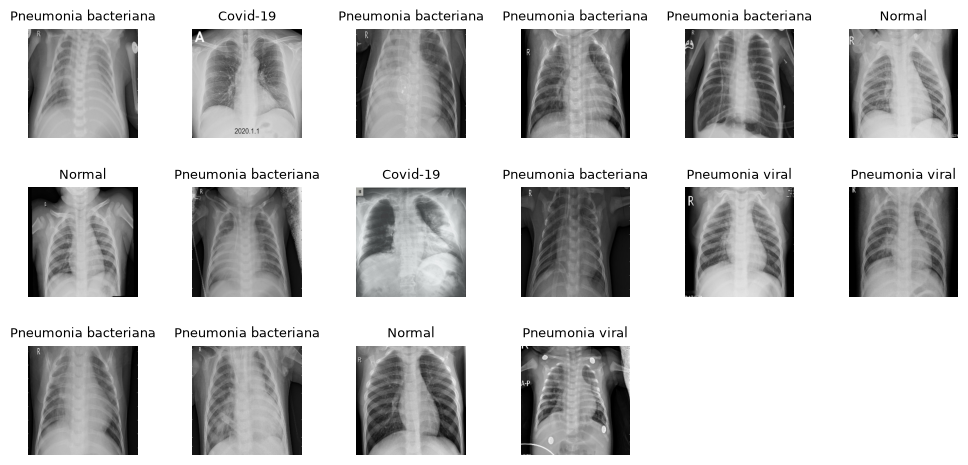

In [5]:
plt.figure(figsize=(12, 12))
for images, labels in train_ds.take(1):
    n = min(36, images.shape[0])
    for i in range(n):
        ax = plt.subplot(6, 6, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(LABELS_NAMES[int(np.argmax(labels[i]))], fontsize=9)
        plt.axis('off')
plt.subplots_adjust(wspace=0.5)
plt.show()

## Data augmentation

Camadas de augmentation nativas do Keras — ativas **somente durante o treino** (em inferência não fazem nada).
Para raio-X usamos transformações leves: rotação pequena, zoom, translação e contraste.
*(Flip horizontal foi evitado propositalmente: inverteria a posição anatômica do coração.)*

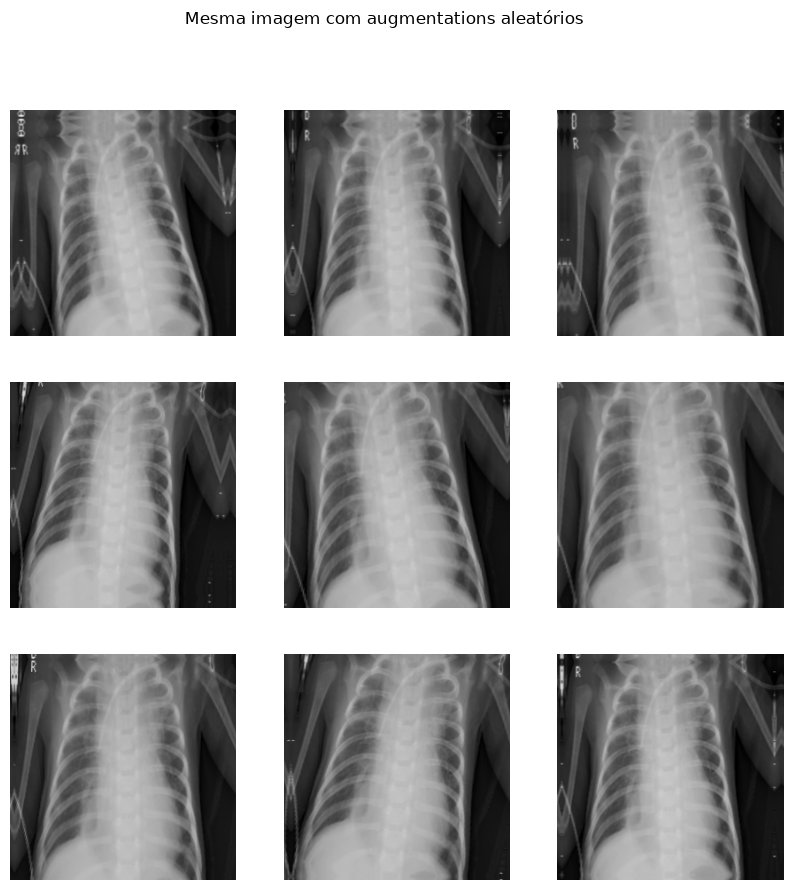

In [6]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.03),        # ±~11 graus
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.1),
], name='data_augmentation')

# Visualização do efeito do augmentation em uma mesma imagem
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    first = tf.expand_dims(images[0], 0)
    for i in range(9):
        augmented = data_augmentation(first, training=True)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.clip(augmented[0].numpy(), 0, 255).astype('uint8'))
        plt.axis('off')
plt.suptitle('Mesma imagem com augmentations aleatórios')
plt.show()

## Construção do modelo (Transfer Learning com ResNet50)

- A ResNet50 é carregada com pesos do ImageNet e usada como **extratora de características**.
- `preprocess_input` aplica a normalização que a ResNet50 espera (muito melhor que `1/255`).
- A base é chamada com `training=False` para manter as camadas de **BatchNormalization em modo de inferência** — essencial para um fine-tuning estável.

In [7]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=IMG_SIZE + (3,))
base_model.trainable = False  # Fase 1: base totalmente congelada

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = keras.Model(inputs, outputs, name='classificador_raiox')
model.summary(show_trainable=True)

Model: "classificador_raiox"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_2     │ (None, 256,     │         0 │ -              │   -   │
│ (InputLayer)      │ 256, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ data_augmentation │ (None, 256,     │         0 │ input_layer_2… │   -   │
│ (Sequential)      │ 256, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ get_item          │ (None, 256,     │         0 │ data_augmenta… │   -   │
│ (GetItem)         │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ get_item_1        │ (None, 256,     │         0 │ data_augmenta… │   -   │
│ (GetItem)         │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ get_item_2        │ (None, 256,     │         0 │ data_augmenta… │   -   │
│ (GetItem)         │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ stack (Stack)     │ (None, 256,     │         0 │ get_item[0][0… │   -   │
│                   │ 256, 3)         │           │ get_item_1[0]… │       │
│                   │                 │           │ get_item_2[0]… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ add (Add)         │ (None, 256,     │         0 │ stack[0][0]    │   -   │
│                   │ 256, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ resnet50          │ (None, 8, 8,    │ 23,587,7… │ add[0][0]      │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ resnet50[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 2048)    │         0 │ global_averag… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 256)     │   524,544 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 256)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 4)       │     1,028 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Callbacks

In [8]:
MODEL_PATH = 'modelo_raiox.keras'  # formato nativo do Keras (substitui o legado .hdf5)

callbacks = [
    keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_accuracy',
                                    save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=8,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=3, min_lr=1e-7, verbose=1),
]

## Fase 1 — Feature extraction (base congelada)

Treinamos apenas a "cabeça" do modelo com learning rate padrão.

In [9]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy'],
)

EPOCHS_PHASE1 = 15

if os.path.exists(MODEL_PATH):
    # Retomada: aproveita o melhor modelo já salvo pela Fase 1 (sem re-treinar)
    print(f'Modelo salvo encontrado ({MODEL_PATH}) — carregando em vez de re-treinar a Fase 1.')
    model = keras.models.load_model(MODEL_PATH)
    history1 = None
else:
    history1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_PHASE1,
        callbacks=callbacks,
    )


Modelo salvo encontrado (modelo_raiox.keras) — carregando em vez de re-treinar a Fase 1.


## Fase 2 — Fine-tuning

Descongelamos o último bloco convolucional da ResNet50 (`conv5_*`) e treinamos com
learning rate bem menor, para ajustar as características de alto nível ao domínio de raio-X.

In [10]:
# Mude para True se quiser re-treinar a Fase 2 (fine-tuning) do zero
EXECUTAR_FINE_TUNING = False

if not EXECUTAR_FINE_TUNING and os.path.exists(MODEL_PATH):
    print('Fine-tuning pulado (EXECUTAR_FINE_TUNING=False) — usando o modelo salvo.')
    history2 = None
else:
    # Se o modelo foi carregado do disco, recupera a base ResNet50 de dentro dele
    base_model = model.get_layer('resnet50')

    base_model.trainable = True
    # Fine-tuning agressivo: descongela a partir do bloco conv4
    fine_tune_from = 'conv4_block1_1_conv'
    set_trainable = False
    for layer in base_model.layers:
        if layer.name == fine_tune_from:
            set_trainable = True
        layer.trainable = set_trainable

    n_trainable = sum(1 for l in base_model.layers if l.trainable)
    print(f'Camadas treináveis na base: {n_trainable} de {len(base_model.layers)}')

    # Recompilar com learning rate baixo é obrigatório após mudar `trainable`
    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        metrics=['accuracy'],
    )

    # Baseline: o checkpoint só substitui o arquivo se SUPERAR a val_accuracy atual
    _, baseline_val_acc = model.evaluate(val_ds, verbose=0)
    print(f'Val_accuracy antes do fine-tuning: {baseline_val_acc:.2%}')

    callbacks_ft = [
        keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_accuracy',
                                        save_best_only=True, verbose=1,
                                        initial_value_threshold=baseline_val_acc),
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                      restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                          patience=3, min_lr=1e-7, verbose=1),
    ]

    EPOCHS_PHASE2 = 25
    initial_epoch = len(history1.epoch) if history1 is not None else EPOCHS_PHASE1
    history2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=initial_epoch + EPOCHS_PHASE2,
        initial_epoch=initial_epoch,
        callbacks=callbacks_ft,
    )


Fine-tuning pulado (EXECUTAR_FINE_TUNING=False) — usando o modelo salvo.


## Avaliação da rede neural

In [11]:
# Curvas de treinamento (fases 1 + 2 concatenadas, quando disponíveis)
hists = [h for h in (history1, history2) if h is not None]
if not hists:
    print('Sem histórico de treino nesta sessão (modelo carregado do disco) — nada a plotar.')
else:
    acc = sum((h.history['accuracy'] for h in hists), [])
    val_acc = sum((h.history['val_accuracy'] for h in hists), [])
    loss = sum((h.history['loss'] for h in hists), [])
    val_loss = sum((h.history['val_loss'] for h in hists), [])
    # Marca o início do fine-tuning apenas quando as duas fases rodaram nesta sessão
    boundary = len(history1.epoch) - 0.5 if len(hists) == 2 else None

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(acc, label='Treino')
    ax1.plot(val_acc, label='Validação')
    ax1.set_title('Taxa de acerto')
    ax1.set_xlabel('Época')

    ax2.plot(loss, label='Treino')
    ax2.plot(val_loss, label='Validação')
    ax2.set_title('Erro (loss)')
    ax2.set_xlabel('Época')

    if boundary is not None:
        ax1.axvline(boundary, color='gray', ls='--', label='Início do fine-tuning')
        ax2.axvline(boundary, color='gray', ls='--', label='Início do fine-tuning')
    ax1.legend(); ax2.legend()
    plt.show()


Sem histórico de treino nesta sessão (modelo carregado do disco) — nada a plotar.


In [12]:
# Carrega o melhor modelo salvo pelo checkpoint e avalia no conjunto de teste
best_model = keras.models.load_model(MODEL_PATH)
test_loss, test_acc = best_model.evaluate(test_ds, verbose=0)
print(f'Loss no teste:     {test_loss:.4f}')
print(f'Acurácia no teste: {test_acc:.2%}')

Loss no teste:     1.9632
Acurácia no teste: 70.00%


In [13]:
# Predições em todo o conjunto de teste
y_prob = best_model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.concatenate([np.argmax(labels, axis=1) for _, labels in test_ds])

print(f'Acurácia: {accuracy_score(y_true, y_pred):.2%}')

Acurácia: 70.00%


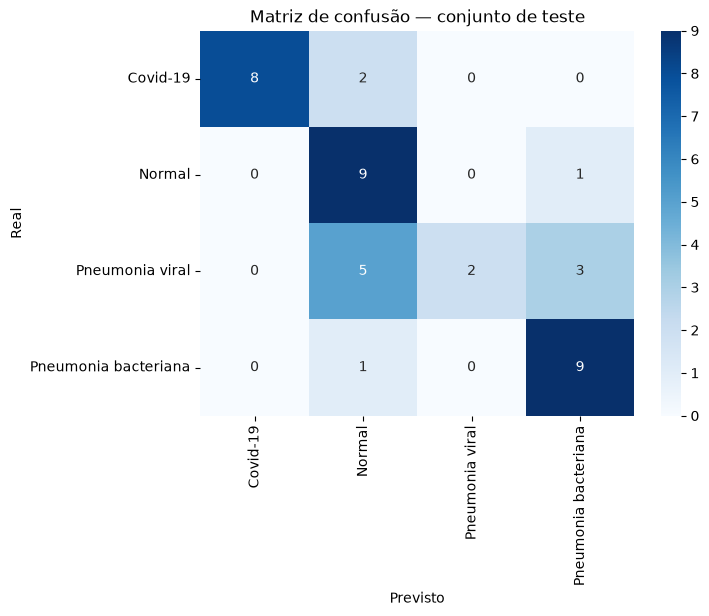

In [14]:
# Matriz de confusão
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[LABELS_NAMES[i] for i in range(4)],
            yticklabels=[LABELS_NAMES[i] for i in range(4)])
plt.xlabel('Previsto'); plt.ylabel('Real')
plt.title('Matriz de confusão — conjunto de teste')
plt.show()

In [15]:
print(classification_report(y_true, y_pred,
      target_names=[LABELS_NAMES[i] for i in range(4)]))

                      precision    recall  f1-score   support

            Covid-19       1.00      0.80      0.89        10
              Normal       0.53      0.90      0.67        10
     Pneumonia viral       1.00      0.20      0.33        10
Pneumonia bacteriana       0.69      0.90      0.78        10

            accuracy                           0.70        40
           macro avg       0.81      0.70      0.67        40
        weighted avg       0.81      0.70      0.67        40



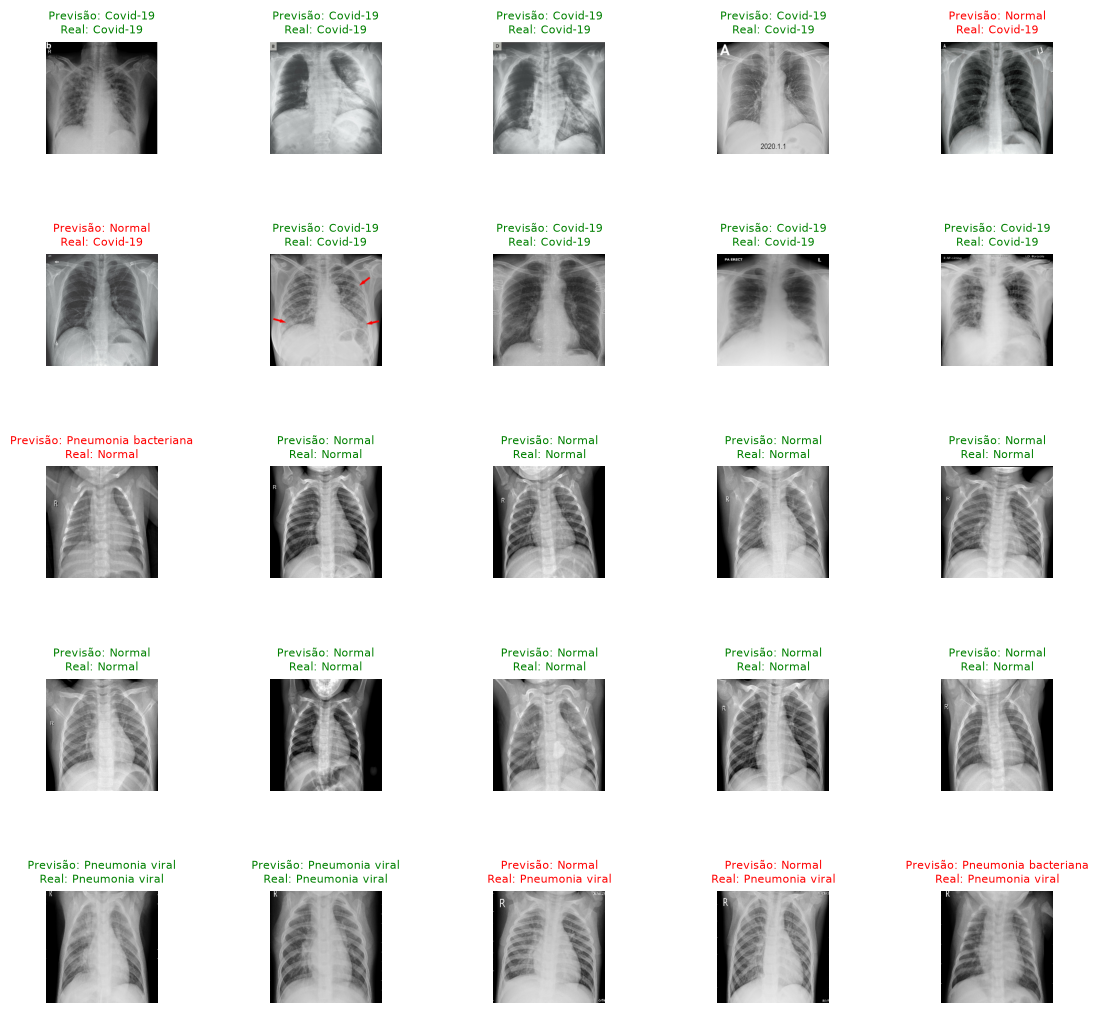

In [16]:
# Visualização das predições
test_images = np.concatenate([imgs.numpy() for imgs, _ in test_ds])
fig, axes = plt.subplots(5, 5, figsize=(13, 13))
axes = axes.ravel()
for i in range(min(25, len(test_images))):
    axes[i].imshow(test_images[i].astype('uint8'))
    ok = y_pred[i] == y_true[i]
    axes[i].set_title(f'Previsão: {LABELS_NAMES[y_pred[i]]}\nReal: {LABELS_NAMES[y_true[i]]}',
                      fontsize=8, color='green' if ok else 'red')
    axes[i].axis('off')
plt.subplots_adjust(wspace=1.0, hspace=0.4)
plt.show()

## Test-Time Augmentation (TTA)

Em vez de uma única predição por imagem, fazemos a **média de várias predições com
variações leves** (rotação, zoom, deslocamento). Isso costuma dar 1–3 pontos de
acurácia "de graça", sem re-treinar nada. Obs.: não usamos flip horizontal —
em raio-X de tórax a posição do coração importa.

In [17]:
# Test-Time Augmentation: média de N predições sobre variações leves
aug_tta = keras.Sequential([
    layers.RandomRotation(0.02),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.03, 0.03),
])

N_TTA = 10
probs_tta = best_model.predict(test_images, verbose=0)  # passada original
for _ in range(N_TTA - 1):
    imgs_aug = aug_tta(test_images, training=True)
    probs_tta += best_model.predict(imgs_aug, verbose=0)
probs_tta /= N_TTA

y_pred_tta = np.argmax(probs_tta, axis=1)
print(f'Acurácia sem TTA: {accuracy_score(y_true, y_pred):.2%}')
print(f'Acurácia com TTA (média de {N_TTA} passadas): {accuracy_score(y_true, y_pred_tta):.2%}')
print()
print(classification_report(y_true, y_pred_tta,
      target_names=[LABELS_NAMES[i] for i in range(4)]))


Acurácia sem TTA: 70.00%
Acurácia com TTA (média de 10 passadas): 80.00%

                      precision    recall  f1-score   support

            Covid-19       1.00      0.80      0.89        10
              Normal       0.64      0.90      0.75        10
     Pneumonia viral       1.00      0.50      0.67        10
Pneumonia bacteriana       0.77      1.00      0.87        10

            accuracy                           0.80        40
           macro avg       0.85      0.80      0.79        40
        weighted avg       0.85      0.80      0.79        40



## Classificação de uma única imagem

Função utilitária para classificar qualquer imagem local — sem OpenCV nem `cv2_imshow` do Colab.

In [18]:
# Pipeline de TTA para imagem única (mesmas variações leves usadas no teste)
aug_tta_single = keras.Sequential([
    layers.RandomRotation(0.02),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.03, 0.03),
])

def classificar_imagem(caminho, modelo=None, n_tta=10):
    """Classifica uma radiografia local com TTA e exibe o resultado."""
    if modelo is None:
        modelo = keras.models.load_model(MODEL_PATH)

    img = keras.utils.load_img(caminho, target_size=IMG_SIZE)
    arr = keras.utils.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)  # (1, 256, 256, 3)

    # TTA: média da predição original + (n_tta - 1) variações leves
    prob = modelo.predict(arr, verbose=0)[0]
    for _ in range(n_tta - 1):
        prob += modelo.predict(aug_tta_single(arr, training=True), verbose=0)[0]
    prob /= n_tta
    classe = int(np.argmax(prob))

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'{LABELS_NAMES[classe]} — confiança: {prob[classe]:.1%}')
    plt.show()

    for i, p in enumerate(prob):
        print(f'  {LABELS_NAMES[i]:<22} {p:.2%}')
    return classe, prob


Imagem: Test\0\1-s2.0-S0929664620300449-gr2_lrg-b.jpg


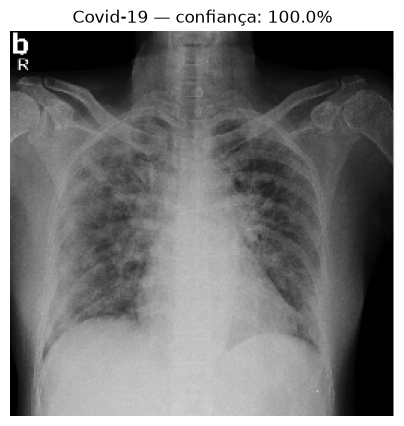

  Covid-19               100.00%
  Normal                 0.00%
  Pneumonia viral        0.00%
  Pneumonia bacteriana   0.00%


In [19]:
# Exemplo: classifica a primeira imagem da pasta Test/0 (Covid-19)
exemplo_dir = os.path.join(TEST_DIR, '0')
exemplo = os.path.join(exemplo_dir, sorted(os.listdir(exemplo_dir))[0])
print('Imagem:', exemplo)
classificar_imagem(exemplo, best_model);

## Conclusões

- **Modelo recomendado para inferência:** `modelo_raiox_mendeley_ft.keras` — ResNet50 com *fine-tuning* do bloco `conv5`, treinada no subconjunto balanceado do Mendeley. Atinge **92,5% com TTA** no `Test/` original (vs. 80% do modelo inicial). Carregue com `keras.models.load_model('modelo_raiox_mendeley_ft.keras')`.
- Modelos preservados para comparação: `modelo_raiox.keras` / `modelo_raiox_backup_80pct.keras` (baseline ~80%) e `modelo_raiox_mendeley.keras` (feature extraction, 82,5%).
- As principais melhorias de desempenho vieram de: pré-processamento correto da ResNet50, validação para monitorar overfitting, augmentation, treinamento em 2 fases (feature extraction + fine-tuning) e, sobretudo, **expandir o dataset** (532 → 4.782 imagens balanceadas) somado ao **fine-tuning do `conv5`**.
- Para uso clínico real seria necessário um conjunto de teste muito maior e validação externa; os 40 exemplos do `Test/` servem apenas como indicativo.